# Moller scattering of Lorentz-covariant vortex packets

Рабочий notebook для состояний (4), двумерной нормировки (17)-(18), S-матрицы (31), поперечных формул (46)/(56), дифференциальной и полной вероятности и среднего полного импульса. Используются только приближения из `QED_with_vortex_packets-2.pdf`.

Единицы: $\hbar=c=1$; энергии и импульсы в MeV, прицельный параметр в MeV$^{-1}$. Все конечные интервалы и числа узлов задаются явно ниже.

In [ ]:
import os
import pprint
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if (ROOT / 'src').exists():
    sys.path.insert(0, str(ROOT / 'src'))

import moller_vortex as mv

print('REAL_DTYPE   =', mv.REAL_DTYPE)
print('COMPLEX_DTYPE=', mv.COMPLEX_DTYPE)

REAL_DTYPE   = <class 'numpy.float64'>
COMPLEX_DTYPE= <class 'numpy.complex128'>


## 1. Параметры пакетов

Глобальный тип меняется одной строкой `REAL_DTYPE` в `src/moller_vortex/config.py`. Здесь заданы встречные пакеты около $\pm10$ MeV. Ширина $\sigma_\perp$ получена из гауссовой координатной ширины.

In [11]:
coordinate_width_nm = 1.0
sigma_perp = mv.spatial_width_nm_to_momentum_mev(coordinate_width_nm)

packet1 = mv.VortexPacket(
    ell=1, sigma_perp=sigma_perp, sigma_parallel=0.05,
    sigma_energy=0.05, k0_z=10.0,
)
packet2 = mv.VortexPacket(
    ell=-1, sigma_perp=sigma_perp, sigma_parallel=0.05,
    sigma_energy=0.05, k0_z=-10.0,
)

impact_nm = 5
impact = np.array((0.0, impact_nm / mv.HBARC_MEV_NM))  # MeV^-1
sigma_total = np.hypot(packet1.sigma_perp, packet2.sigma_perp)

print('sigma_perp =', sigma_perp, 'MeV')
print('impact     =', impact, 'MeV^-1')

sigma_perp = 0.0001973269804 MeV
impact     = [    0.        25338.6535884] MeV^-1


## 2. Двумерная нормировка

`Axis(start, stop, points, rule)` полностью задаёт квадратуру. Для конечных непериодических интервалов используется Gauss-Legendre; для углов ниже — endpoint-free periodic trapezoid. Сначала сравниваются три разрешения при неизменных интервалах. Затем интервалы тоже следует расширять до стабилизации результата.

In [3]:
k_perp_max = 8.0 * np.sqrt(max(abs(packet1.ell), abs(packet2.ell)) + 1.0) * sigma_perp
z_half_width = 8.0 * max(packet1.sigma_parallel, packet1.sigma_energy)

def norm_grid(packet, n_perp, n_z):
    return mv.NormalizationGrid(
        k_perp=mv.Axis(0.0, k_perp_max, n_perp, 'gauss'),
        k_z=mv.Axis(packet.k0_z - z_half_width, packet.k0_z + z_half_width, n_z, 'gauss'),
        batch_size=64,
    )

normalization_scan = []
for n_perp, n_z in ((32, 48), (48, 72), (64, 96)):
    value = mv.normalization(packet1, norm_grid(packet1, n_perp, n_z))
    normalization_scan.append((n_perp, n_z, value))

N1, norm_info1 = mv.normalization(packet1, norm_grid(packet1, 64, 96), return_info=True)
N2, norm_info2 = mv.normalization(packet2, norm_grid(packet2, 64, 96), return_info=True)
norms = (N1, N2)

print('n_perp  n_z       N1')
for row in normalization_scan:
    print(f'{row[0]:6d} {row[1]:4d}  {row[2]:.12e}')
print('N1, N2 =', norms)
print('N1^2 I1 =', N1**2 * norm_info1['integral_without_norm'])
print('N2^2 I2 =', N2**2 * norm_info2['integral_without_norm'])

n_perp  n_z       N1
    32   48  8.047273044673e+05
    48   72  8.047272878626e+05
    64   96  8.047272878626e+05
N1, N2 = (804727.287862576, 804727.287862576)
N1^2 I1 = 1.0000000000000002
N2^2 I2 = 1.0000000000000002


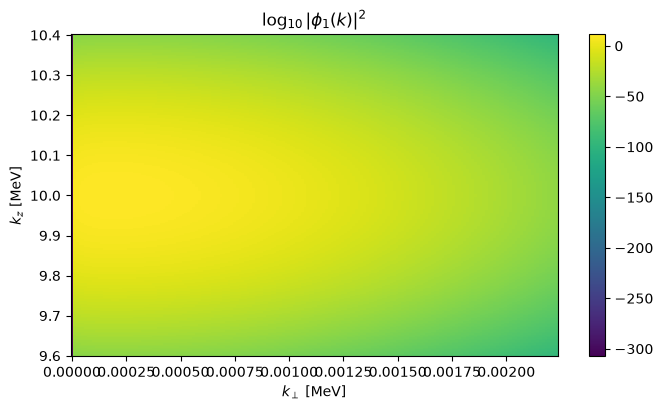

In [4]:
k_perp_plot = np.linspace(0.0, k_perp_max, 180)
k_z_plot = np.linspace(packet1.k0_z - z_half_width, packet1.k0_z + z_half_width, 220)
KP, KZ = np.meshgrid(k_perp_plot, k_z_plot, indexing='xy')
momenta = np.stack((KP, np.zeros_like(KP), KZ), axis=-1)
density = np.abs(mv.wave_packet(momenta, packet1, norm=N1))**2

fig, ax = plt.subplots(figsize=(7.0, 4.2))
image = ax.pcolormesh(KP, KZ, np.log10(density + np.finfo(float).tiny), shading='auto')
ax.set(xlabel=r'$k_\perp$ [MeV]', ylabel=r'$k_z$ [MeV]', title=r'$\log_{10}|\phi_1(k)|^2$')
fig.colorbar(image, ax=ax)
fig.tight_layout()
plt.show()

## 3. Проверка применимости приближений

Значения ниже соответствуют разделу 3 PDF. Они должны быть $\ll1$; функция намеренно не вводит произвольный порог `pass/fail`.

In [5]:
checks = mv.approximation_parameters(packet1, packet2)
pprint.pp(checks, sort_dicts=False)

{'packet1': {'central_energy': 10.013047484502463,
             'velocity': 0.9986969517000037,
             'effective_sigma': 0.03537838141553947,
             'energy_expansion_longitudinal': 0.0024983695967736755,
             'energy_expansion_transverse': 2.7869885999814195e-05,
             'mass_over_energy': 0.05103330936869026,
             'smooth_prefactor': 0.0024951141005178376,
             'transverse_spreading': 7.782515291399259e-08,
             'longitudinal_spreading': 6.515240115371278e-06,
             'transverse_phase': 7.782515291399259e-08,
             'longitudinal_phase': 1.6288100288428195e-06},
 'packet2': {'central_energy': 10.013047484502463,
             'velocity': -0.9986969517000037,
             'effective_sigma': 0.03537838141553947,
             'energy_expansion_longitudinal': 0.0024983695967736755,
             'energy_expansion_transverse': 2.7869885999814195e-05,
             'mass_over_energy': 0.05103330936869026,
             'smooth_pref

## 4. S-матрица в одной точке

`return_info=True` возвращает отдельно $L$, $T$, энергии и параметр контроля разложения знаменателя $\sqrt{|\ell_1|+1}\,\sigma_{1\perp}/|k_{3\perp}|$.

In [6]:
k3_perp = np.array((0.020, 0.004))
K_perp = np.array((0.50 * sigma_total, -0.25 * sigma_total))
k4_perp = K_perp - k3_perp
k3 = np.array((*k3_perp, np.sqrt(packet1.k0_z**2 - np.dot(k3_perp, k3_perp))))
k4 = np.array((*k4_perp, -np.sqrt(packet2.k0_z**2 - np.dot(k4_perp, k4_perp))))

S, S_info = mv.s_matrix(
    k3, k4, packet1, packet2, norms=norms, impact=impact, return_info=True
)
print('S =', S)
print('|S|^2 =', abs(S)**2)
print('L =', S_info['longitudinal_factor'])
print('T =', S_info['transverse_integral'])
print('transverse expansion ratio =', S_info['transverse_expansion_ratio'])

S = (14319.615397530186+277197.18564064894j)
|S|^2 = 77043331112.22957
L = 3.1456916416966187
T = (-7.16609510769568e-12+3.701903596429478e-13j)
transverse expansion ratio = 0.013682164343551495


## 5. Вероятностные квадратуры

`FAST_DEMO=True` даёт быстрый диагностический прогон. Для результатов увеличьте числа узлов и интервалы и повторяйте расчёт до стабилизации. Внутренний четырёхмерный интеграл векторизован и разбит на batch; независимые точки $K_\perp$ параллелятся параметром `workers`.

In [7]:
FAST_DEMO = True
WORKERS = min(2, os.cpu_count() or 1)

if FAST_DEMO:
    n_k3_perp, n_k3_phi, n_z = 12, 16, 16
    n_K, n_K_phi, n_map = 8, 12, 11
else:
    n_k3_perp, n_k3_phi, n_z = 28, 48, 40
    n_K, n_K_phi, n_map = 24, 48, 41

probability_grid = mv.ProbabilityGrid(
    k3_perp=mv.Axis(0.010, 0.050, n_k3_perp, 'gauss'),
    k3_phi=mv.Axis(0.0, 2.0 * np.pi, n_k3_phi, 'periodic'),
    k3_z=mv.Axis(9.70, 10.30, n_z, 'gauss'),
    k4_z=mv.Axis(-10.30, -9.70, n_z, 'gauss'),
    K_perp=mv.Axis(0.0, 5.0 * sigma_total, n_K, 'gauss'),
    K_phi=mv.Axis(0.0, 2.0 * np.pi, n_K_phi, 'periodic'),
    batch_size=48,
)

w0 = mv.differential_probability(
    np.zeros(2), packet1, packet2, probability_grid, norms=norms, impact=impact
)
print('dP/d^2K at K=0 =', w0)

dP/d^2K at K=0 = 0.13916191917428647


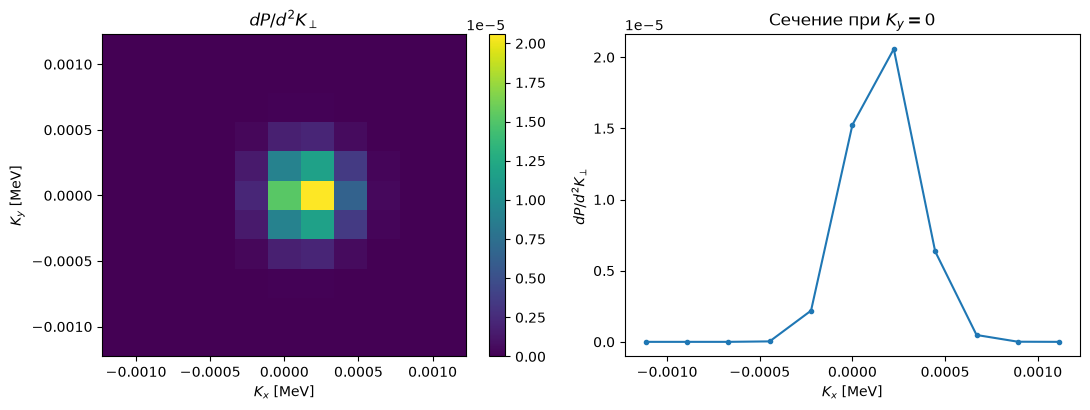

In [12]:
K_limit = 4.0 * sigma_total
Kx = np.linspace(-K_limit, K_limit, n_map)
Ky = np.linspace(-K_limit, K_limit, n_map)
w_map = mv.differential_probability_grid(
    Kx, Ky, packet1, packet2, probability_grid,
    norms=norms, impact=impact, workers=WORKERS,
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
mesh = axes[0].pcolormesh(Kx, Ky, w_map, shading='auto')
axes[0].set(xlabel=r'$K_x$ [MeV]', ylabel=r'$K_y$ [MeV]', title=r'$dP/d^2K_\perp$')
fig.colorbar(mesh, ax=axes[0])
axes[1].plot(Kx, w_map[len(Ky)//2], marker='o', ms=3)
axes[1].set(xlabel=r'$K_x$ [MeV]', ylabel=r'$dP/d^2K_\perp$', title=r'Сечение при $K_y=0$')
fig.tight_layout()
plt.show()

## 6. Полная вероятность и средний полный импульс

`return_mean=True` вычисляет $P$ и $\langle K\rangle$ за один проход. Это интегралы только по заданным выше конечным областям.

In [9]:
P, mean_K = mv.total_probability(
    packet1, packet2, probability_grid, norms=norms, impact=impact,
    workers=WORKERS, return_mean=True,
)
print('P on selected domain =', P)
print('<Kx, Ky, Kz> [MeV]  =', mean_K)

P on selected domain = 1.7498643061042957e-08
<Kx, Ky, Kz> [MeV]  = [ 1.14827924e-06  1.58686041e-20 -8.15535618e-15]


## 7. Шаблон проверки сходимости вероятности

Сканирование выключено по умолчанию, чтобы случайно не запустить длинный расчёт. Сначала проверяйте числа узлов при фиксированных интервалах, затем расширяйте интервалы.

In [10]:
RUN_PROBABILITY_CONVERGENCE = False

if RUN_PROBABILITY_CONVERGENCE:
    for outer_points in (8, 12, 16):
        scan_grid = mv.ProbabilityGrid(
            k3_perp=probability_grid.k3_perp,
            k3_phi=probability_grid.k3_phi,
            k3_z=probability_grid.k3_z,
            k4_z=probability_grid.k4_z,
            K_perp=mv.Axis(0.0, 5.0 * sigma_total, outer_points, 'gauss'),
            K_phi=probability_grid.K_phi,
            batch_size=probability_grid.batch_size,
        )
        value = mv.total_probability(
            packet1, packet2, scan_grid, norms=norms, impact=impact, workers=WORKERS
        )
        print(f'n_K={outer_points:2d}: P={value:.12e}')
else:
    print('Set RUN_PROBABILITY_CONVERGENCE=True to run the scan.')

Set RUN_PROBABILITY_CONVERGENCE=True to run the scan.
